# Physical Building Thermal Model

This notebook demonstrates the reduced-order building thermal
model used in the project.

The model represents the indoor air and building thermal mass
as two interacting thermal states. Outdoor temperature,
internal gains, solar gains and HVAC input are used to simulate
indoor thermal behaviour.

The purpose of this model is to provide a controlled
computational environment for investigating data-driven
prediction and HVAC optimisation.

## Thermal Model

The indoor air temperature is described by:

$$
C_a \frac{dT_a}{dt}
=
\frac{T_o-T_a}{R_o}
+
\frac{T_m-T_a}{R_m}
+
Q_{internal}
+
Q_{solar}
+
Q_{HVAC}
$$

The thermal mass is described by:

$$
C_m \frac{dT_m}{dt}
=
\frac{T_a-T_m}{R_m}
$$

where:

- $T_a$ is indoor air temperature
- $T_m$ is building thermal mass temperature
- $T_o$ is outdoor temperature
- $Q_{HVAC}$ is HVAC thermal input
- $Q_{internal}$ represents internal heat gains
- $Q_{solar}$ represents solar gains

In [1]:
import sys
import os

sys.path.append(
    os.path.abspath("../src")
)

import numpy as np
import matplotlib.pyplot as plt

from model import BuildingThermalModel

In [2]:
building = BuildingThermalModel()

print(building)

In [6]:
T_air = 22.0
T_mass = 22.0
T_out = 5.0

Q_internal = 500.0
Q_solar = 0.0
Q_HVAC = 2000.0

T_air_new, T_mass_new = building.step(
    T_air=T_air,
    T_mass=T_mass,
    T_out=T_out,
    Q_internal=Q_internal,
    Q_solar=Q_solar,
    Q_HVAC=Q_HVAC,
)

print("New air temperature:", T_air_new)
print("New mass temperature:", T_mass_new)

New air temperature: 23.188
New mass temperature: 22.0


In [8]:
hours = 24

T_air = 22.0
T_mass = 22.0

T_air_history = []
T_mass_history = []

for hour in range(hours):

    T_out = 5 + 5 * np.sin(
        2 * np.pi * hour / 24
    )

    Q_internal = 500.0
    Q_solar = 0.0
    Q_HVAC = 1000.0

    T_air, T_mass = building.step(
        T_air=T_air,
        T_mass=T_mass,
        T_out=T_out,
        Q_internal=Q_internal,
        Q_solar=Q_solar,
        Q_HVAC=Q_HVAC,
    )

    T_air_history.append(T_air)
    T_mass_history.append(T_mass)

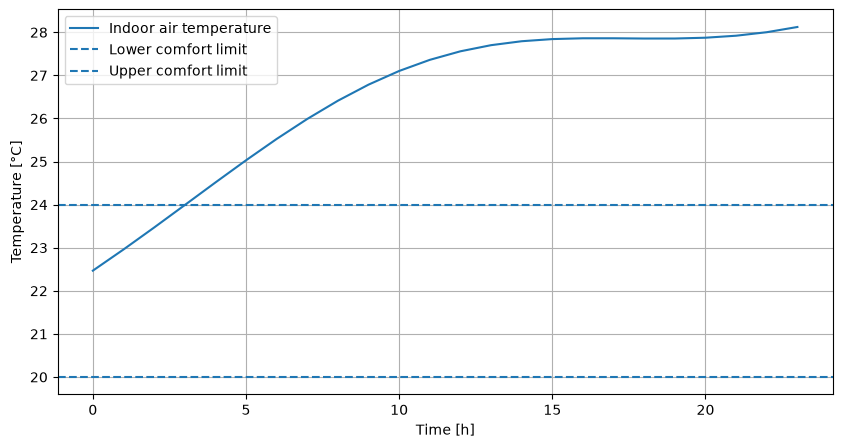

In [10]:
plt.figure(figsize=(10, 5))

plt.plot(
    T_air_history,
    label="Indoor air temperature"
)

plt.axhline(
    20,
    linestyle="--",
    label="Lower comfort limit"
)

plt.axhline(
    24,
    linestyle="--",
    label="Upper comfort limit"
)

plt.xlabel("Time [h]")
plt.ylabel("Temperature [°C]")

plt.legend()
plt.grid()

plt.show()